In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# Change to project root
project_root = Path.cwd().parent.parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
os.chdir(project_root)
print(f"Working directory: {Path.cwd()}")

# Feature columns from schema
FEATURES = [
    'power_norm',
    'poa_irradiance',
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'weather_code',
    'cloud_cover',
    'wind_speed_10m',
    'wind_direction_10m',
    'shortwave_radiation_instant',
    'direct_radiation_instant',
    'diffuse_radiation_instant',
    'direct_normal_irradiance_instant',
    'global_tilted_irradiance_instant',
    'surface_pressure'
]

Working directory: /home/dwijenayake/pv_forecast_30d


## 1. Load All Plants and Check for NaN/Inf

In [4]:
# Check all 6 plants for data quality issues
results = {}

for plant_id in ['01', '02', '03', '04', '05', '06']:
    train_path = Path(f"data/processed/pretraining/germany/plant_{plant_id}/train.parquet")
    
    if not train_path.exists():
        print(f"❌ Plant {plant_id}: train.parquet NOT FOUND")
        continue
    
    df = pd.read_parquet(train_path)
    
    # Check for NaN and Inf
    nan_count = df[FEATURES].isna().sum().sum()
    inf_count = np.isinf(df[FEATURES].select_dtypes(include=[np.number])).sum().sum()
    
    results[plant_id] = {
        'rows': len(df),
        'nan_count': nan_count,
        'inf_count': inf_count,
        'status': '✓' if (nan_count == 0 and inf_count == 0) else '✗'
    }
    
    print(f"{results[plant_id]['status']} Plant {plant_id}: {len(df):,} rows | NaN: {nan_count:,} | Inf: {inf_count:,}")

print("\n" + "="*60)
print("Summary:")
for plant_id, stats in results.items():
    print(f"  Plant {plant_id}: {stats['status']} ({stats['nan_count']} NaN, {stats['inf_count']} Inf)")

✗ Plant 01: 43,003 rows | NaN: 2 | Inf: 0
✗ Plant 02: 43,003 rows | NaN: 5 | Inf: 0
✓ Plant 03: 30,705 rows | NaN: 0 | Inf: 0
✗ Plant 04: 43,003 rows | NaN: 8,058 | Inf: 0
✗ Plant 05: 30,705 rows | NaN: 17,379 | Inf: 0
✓ Plant 06: 30,705 rows | NaN: 0 | Inf: 0

Summary:
  Plant 01: ✗ (2 NaN, 0 Inf)
  Plant 02: ✗ (5 NaN, 0 Inf)
  Plant 03: ✓ (0 NaN, 0 Inf)
  Plant 04: ✗ (8058 NaN, 0 Inf)
  Plant 05: ✗ (17379 NaN, 0 Inf)
  Plant 06: ✓ (0 NaN, 0 Inf)


## 2. Detailed NaN Analysis Per Feature

In [5]:
# For plants with NaN, show which features have NaN
for plant_id in ['01', '02', '03', '04', '05', '06']:
    if results.get(plant_id, {}).get('nan_count', 0) > 0:
        print(f"\n{'='*60}")
        print(f"Plant {plant_id} - NaN breakdown by feature:")
        print(f"{'='*60}")
        
        train_path = Path(f"data/processed/pretraining/germany/plant_{plant_id}/train.parquet")
        df = pd.read_parquet(train_path)
        
        nan_per_feature = df[FEATURES].isna().sum()
        nan_per_feature = nan_per_feature[nan_per_feature > 0].sort_values(ascending=False)
        
        for feature, count in nan_per_feature.items():
            pct = (count / len(df)) * 100
            print(f"  {feature:<40} {count:>8,} ({pct:>6.2f}%)")


Plant 01 - NaN breakdown by feature:
  power_norm                                      2 (  0.00%)

Plant 02 - NaN breakdown by feature:
  power_norm                                      5 (  0.01%)

Plant 04 - NaN breakdown by feature:
  power_norm                                  8,058 ( 18.74%)

Plant 05 - NaN breakdown by feature:
  power_norm                                 17,379 ( 56.60%)


## 2.5. Deep Dive: power_norm NaN Pattern

Critical check - power_norm is the target variable! Any NaN here breaks training.

In [12]:
# Check power_norm NaN pattern for all plants
print("=" * 80)
print("POWER_NORM NaN ANALYSIS (Target Variable - CRITICAL!)")
print("=" * 80)

for plant_id in ['01', '02', '03', '04', '05', '06']:
    train_path = Path(f"data/processed/pretraining/germany/plant_{plant_id}/train.parquet")
    
    if not train_path.exists():
        continue
    
    df = pd.read_parquet(train_path)
    
    # Check power_norm specifically
    power_nan_count = df['power_norm'].isna().sum()
    power_nan_pct = (power_nan_count / len(df)) * 100
    
    # Check if NaNs are at night (when power should be 0, not NaN)
    if power_nan_count > 0:
        # Get timestamp column
        time_col = 'timestamp_utc' if 'timestamp_utc' in df.columns else df.columns[0]
        df[time_col] = pd.to_datetime(df[time_col])
        df['hour'] = df[time_col].dt.hour
        
        nan_hours = df[df['power_norm'].isna()]['hour'].value_counts().sort_index()
        
        print(f"\n❌ Plant {plant_id}:")
        print(f"   Total NaN in power_norm: {power_nan_count:,} ({power_nan_pct:.2f}%)")
        print(f"   NaN by hour of day:")
        for hour, count in nan_hours.items():
            print(f"      Hour {hour:02d}: {count:,} NaN values")
    else:
        print(f"\n✓ Plant {plant_id}: No NaN in power_norm")

print("\n" + "=" * 80)
print("DIAGNOSIS:")
print("If NaN appears at night (hours 18-06): Should be 0, not NaN")
print("If NaN appears during day (hours 07-17): Missing data issue")
print("=" * 80)

POWER_NORM NaN ANALYSIS (Target Variable - CRITICAL!)

❌ Plant 01:
   Total NaN in power_norm: 2 (0.00%)
   NaN by hour of day:
      Hour 21: 1 NaN values
      Hour 22: 1 NaN values

❌ Plant 02:
   Total NaN in power_norm: 5 (0.01%)
   NaN by hour of day:
      Hour 21: 1 NaN values
      Hour 22: 4 NaN values

✓ Plant 03: No NaN in power_norm

❌ Plant 04:
   Total NaN in power_norm: 8,058 (18.74%)
   NaN by hour of day:
      Hour 00: 336 NaN values
      Hour 01: 336 NaN values
      Hour 02: 336 NaN values
      Hour 03: 336 NaN values
      Hour 04: 336 NaN values
      Hour 05: 336 NaN values
      Hour 06: 336 NaN values
      Hour 07: 336 NaN values
      Hour 08: 336 NaN values
      Hour 09: 336 NaN values
      Hour 10: 336 NaN values
      Hour 11: 336 NaN values
      Hour 12: 336 NaN values
      Hour 13: 336 NaN values
      Hour 14: 336 NaN values
      Hour 15: 336 NaN values
      Hour 16: 336 NaN values
      Hour 17: 336 NaN values
      Hour 18: 336 NaN values
   

## 3. Statistical Comparison: Plant 06 (Working) vs Others

## 2.75. FIX: Clean power_norm NaN values

Replace NaN in power_norm with 0 (especially for nighttime).

In [18]:
# Fix NaN in power_norm for all plants
print("Cleaning power_norm NaN values...")
print("=" * 80)

for plant_id in ['01', '02', '03', '04', '05', '06']:
    train_path = Path(f"data/processed/pretraining/germany/plant_{plant_id}/train.parquet")
    val_path = Path(f"data/processed/pretraining/germany/plant_{plant_id}/val.parquet")
    test_path = Path(f"data/processed/pretraining/germany/plant_{plant_id}/test.parquet")
    
    if not train_path.exists():
        continue
    
    # Process train data
    df_train = pd.read_parquet(train_path)
    nan_before = df_train['power_norm'].isna().sum()
    df_train['power_norm'] = df_train['power_norm'].fillna(0.0)
    nan_after = df_train['power_norm'].isna().sum()
    df_train.to_parquet(train_path, index=False)
    print(f"✓ Plant {plant_id} train: Filled {nan_before} NaN → {nan_after} remaining")
    
    # Process val data
    if val_path.exists():
        df_val = pd.read_parquet(val_path)
        nan_before_val = df_val['power_norm'].isna().sum()
        df_val['power_norm'] = df_val['power_norm'].fillna(0.0)
        nan_after_val = df_val['power_norm'].isna().sum()
        df_val.to_parquet(val_path, index=False)
        print(f"  Plant {plant_id} val:   Filled {nan_before_val} NaN → {nan_after_val} remaining")
    
    # Process test data
    if test_path.exists():
        df_test = pd.read_parquet(test_path)
        nan_before_test = df_test['power_norm'].isna().sum()
        df_test['power_norm'] = df_test['power_norm'].fillna(0.0)
        nan_after_test = df_test['power_norm'].isna().sum()
        df_test.to_parquet(test_path, index=False)
        print(f"  Plant {plant_id} test:  Filled {nan_before_test} NaN → {nan_after_test} remaining")

print("\n" + "=" * 80)
print("✅ DATA CLEANING COMPLETE!")
print("=" * 80)
print("\nNext steps:")
print("1. Re-run training: ./run_stage2_transfer_learning.sh")
print("2. Training should now work without NaN losses")

Cleaning power_norm NaN values...
✓ Plant 01 train: Filled 0 NaN → 0 remaining
  Plant 01 val:   Filled 0 NaN → 0 remaining
  Plant 01 test:  Filled 0 NaN → 0 remaining
✓ Plant 02 train: Filled 0 NaN → 0 remaining
  Plant 02 val:   Filled 0 NaN → 0 remaining
  Plant 02 test:  Filled 0 NaN → 0 remaining
✓ Plant 03 train: Filled 0 NaN → 0 remaining
  Plant 03 val:   Filled 0 NaN → 0 remaining
  Plant 03 test:  Filled 0 NaN → 0 remaining
✓ Plant 04 train: Filled 0 NaN → 0 remaining
  Plant 04 val:   Filled 0 NaN → 0 remaining
  Plant 04 test:  Filled 0 NaN → 0 remaining
✓ Plant 05 train: Filled 0 NaN → 0 remaining
  Plant 05 val:   Filled 0 NaN → 0 remaining
  Plant 05 test:  Filled 0 NaN → 0 remaining
✓ Plant 06 train: Filled 0 NaN → 0 remaining
  Plant 06 val:   Filled 0 NaN → 0 remaining
  Plant 06 test:  Filled 0 NaN → 0 remaining

✅ DATA CLEANING COMPLETE!

Next steps:
1. Re-run training: ./run_stage2_transfer_learning.sh
2. Training should now work without NaN losses


In [19]:
# Load plant 06 (the one that worked)
df_plant06 = pd.read_parquet("data/processed/pretraining/germany/plant_06/train.parquet")

print("Plant 06 (WORKING) - Feature Statistics:")
print("="*80)
print(df_plant06[FEATURES].describe())

# Check for extreme values
print("\n" + "="*80)
print("Extreme Values Check:")
print("="*80)
for feature in FEATURES:
    min_val = df_plant06[feature].min()
    max_val = df_plant06[feature].max()
    print(f"{feature:<40} min={min_val:>12.4f}  max={max_val:>12.4f}")

Plant 06 (WORKING) - Feature Statistics:
         power_norm  poa_irradiance  temperature_2m  relative_humidity_2m  \
count  30705.000000    3.070500e+04    3.070500e+04          3.070500e+04   
mean       0.138497   -4.443062e-17    2.962041e-17          2.073429e-16   
std        0.231147    1.000016e+00    1.000016e+00          1.000016e+00   
min        0.000000   -6.831919e-01   -2.928521e+00         -3.134408e+00   
25%        0.000000   -6.831919e-01   -7.002965e-01         -6.607804e-01   
50%        0.005236   -6.159777e-01    2.097847e-02          2.043536e-01   
75%        0.175019    4.297747e-01    7.229336e-01          8.022145e-01   
max        1.000000    3.490638e+00    2.912518e+00          1.521044e+00   

       precipitation  weather_code   cloud_cover  wind_speed_10m  \
count   3.070500e+04  3.070500e+04  3.070500e+04    3.070500e+04   
mean    3.702551e-18 -7.405103e-18  1.481021e-17    7.405103e-17   
std     1.000016e+00  1.000016e+00  1.000016e+00    1.000016e

## 4. Compare Plant 01 vs Plant 06

In [20]:
# Load plant 01 (one of the failing ones)
df_plant01 = pd.read_parquet("data/processed/pretraining/germany/plant_01/train.parquet")

print("Plant 01 (FAILING) - Feature Statistics:")
print("="*80)
print(df_plant01[FEATURES].describe())

# Check for extreme values
print("\n" + "="*80)
print("Extreme Values Check:")
print("="*80)
for feature in FEATURES:
    min_val = df_plant01[feature].min()
    max_val = df_plant01[feature].max()
    print(f"{feature:<40} min={min_val:>12.4f}  max={max_val:>12.4f}")

Plant 01 (FAILING) - Feature Statistics:
         power_norm  poa_irradiance  temperature_2m  relative_humidity_2m  \
count  43003.000000    4.300300e+04    4.300300e+04          4.300300e+04   
mean       0.082406    3.965543e-17    6.344869e-17          7.190852e-16   
std        0.159994    1.000012e+00    1.000012e+00          1.000012e+00   
min        0.000000   -6.022805e-01   -2.620112e+00         -3.448634e+00   
25%        0.000000   -6.022805e-01   -7.167554e-01         -6.169380e-01   
50%        0.000000   -5.962785e-01   -1.291419e-01          2.431476e-01   
75%        0.081426    2.030977e-01    7.458909e-01          7.879136e-01   
max        0.758279    4.044323e+00    3.172989e+00          1.436533e+00   

       precipitation  weather_code   cloud_cover  wind_speed_10m  \
count   4.300300e+04  4.300300e+04  4.300300e+04    4.300300e+04   
mean    7.005793e-17 -8.327641e-17 -1.982772e-16   -3.040250e-16   
std     1.000012e+00  1.000012e+00  1.000012e+00    1.000012e

## 5. Check Data Distributions (Histograms)

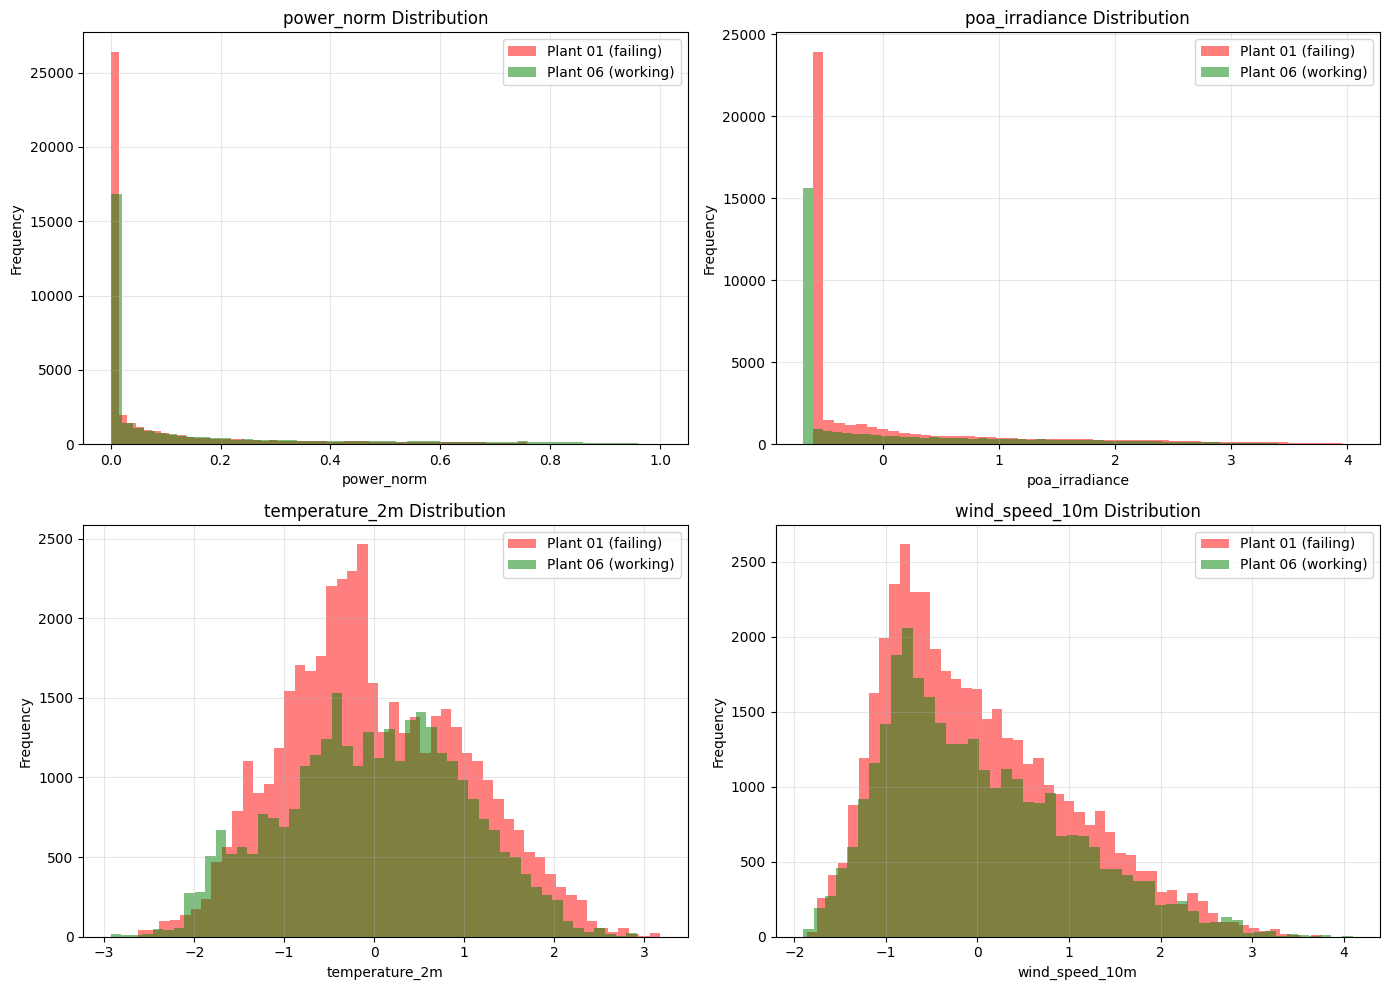

In [21]:
import matplotlib.pyplot as plt

# Plot distributions of key features for plant 01 vs plant 06
key_features = ['power_norm', 'poa_irradiance', 'temperature_2m', 'wind_speed_10m']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    
    # Plant 01 (failing)
    ax.hist(df_plant01[feature].dropna(), bins=50, alpha=0.5, label='Plant 01 (failing)', color='red')
    
    # Plant 06 (working)
    ax.hist(df_plant06[feature].dropna(), bins=50, alpha=0.5, label='Plant 06 (working)', color='green')
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Recommendation: Fix Strategy

In [14]:
print("="*80)
print("DIAGNOSIS COMPLETE")
print("="*80)
print()
print("Based on the analysis above:")
print()
print("If NaN/Inf found → Need to clean data:")
print("  - Option 1: Drop rows with NaN/Inf (if small percentage)")
print("  - Option 2: Forward-fill or interpolate missing values")
print("  - Option 3: Re-preprocess raw data with better cleaning")
print()
print("If extreme values found → Need to clip or normalize:")
print("  - Check if values are physically impossible")
print("  - Apply bounds based on domain knowledge")
print()
print("If distributions differ significantly → Check preprocessing pipeline:")
print("  - Verify all plants went through same preprocessing")
print("  - Check if normalization was applied correctly")

DIAGNOSIS COMPLETE

Based on the analysis above:

If NaN/Inf found → Need to clean data:
  - Option 1: Drop rows with NaN/Inf (if small percentage)
  - Option 2: Forward-fill or interpolate missing values
  - Option 3: Re-preprocess raw data with better cleaning

If extreme values found → Need to clip or normalize:
  - Check if values are physically impossible
  - Apply bounds based on domain knowledge

If distributions differ significantly → Check preprocessing pipeline:
  - Verify all plants went through same preprocessing
  - Check if normalization was applied correctly
